In [1]:
# Import all libraries we need for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/raw/churn.csv')

# Basic info
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())



Matplotlib is building the font cache; this may take a moment.


ModuleNotFoundError: No module named 'seaborn'

In [1]:
# Import all libraries we need for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/raw/churn.csv')

# Basic info
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [2]:
# Check basic statistics of our data
print("First 5 rows:")
print(df.head())

print("\nData Types of each column:")
print(df.dtypes)

print("\nAny Missing Values?")
print(df.isnull().sum())

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies       

In [3]:
# Check data types and missing values
print("Data Types of each column:")
print(df.dtypes)

print("\nAny Missing Values?")
print(df.isnull().sum())

print("\nTotal Customers:", len(df))
print("Churned Customers:", df[df['Churn']=='Yes'].shape[0])
print("Stayed Customers:", df[df['Churn']=='No'].shape[0])

Data Types of each column:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Any Missing Values?
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            

In [4]:
# Check specifically
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].head(10))

object
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object


In [5]:
# Find the problematic rows
print("Rows where TotalCharges is a space:")
problematic = df[df['TotalCharges'].str.strip() == '']
print(problematic.shape[0])
print(problematic[['customerID', 'tenure', 'TotalCharges']])

Rows where TotalCharges is a space:
11
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             


In [6]:
# Fix TotalCharges column
# Step 1: Replace empty spaces with 0
df['TotalCharges'] = df['TotalCharges'].str.strip()
df['TotalCharges'] = df['TotalCharges'].replace('', '0')

# Step 2: Convert from text to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Step 3: Verify the fix
print("Data type now:", df['TotalCharges'].dtype)
print("Missing values:", df['TotalCharges'].isnull().sum())
print("\nFirst 5 values:")
print(df['TotalCharges'].head())

Data type now: float64
Missing values: 0

First 5 values:
0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64


Task was destroyed but it is pending!
task: <Task pending name='Task-78' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Preet\PycharmProjects\silent-churn-mlops\venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-79' coro=<Kernel.shell_main() running at C:\Users\Preet\PycharmProjects\silent-churn-mlops\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Preet\PycharmProjects\silent-churn-mlops\venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\Preet\PycharmProjects\silent-churn-mlops\venv\Lib\site-packages\traitlets\traitlets.py:963: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return super().__new__(mcls, name, bases, classdict, **kwds)
Task was destroyed but it is pending!
task: <Task pending name='Task-79' coro=<Kernel.shell_main() running at C:\Users\Preet\PycharmProjects\silent-churn-mlops\venv\Lib\site-p

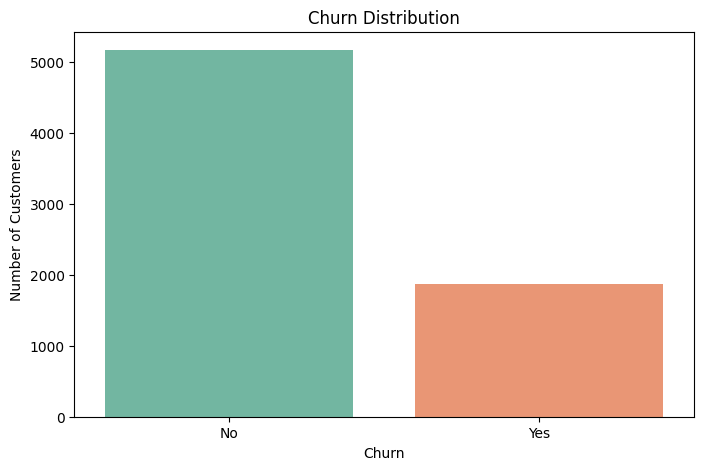

Stayed: 73.5%
Churned: 26.5%


In [7]:
# Visualize Churn Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

# Print percentages
total = len(df)
churned = df[df['Churn']=='Yes'].shape[0]
stayed = df[df['Churn']=='No'].shape[0]
print(f"Stayed: {stayed/total*100:.1f}%")
print(f"Churned: {churned/total*100:.1f}%")

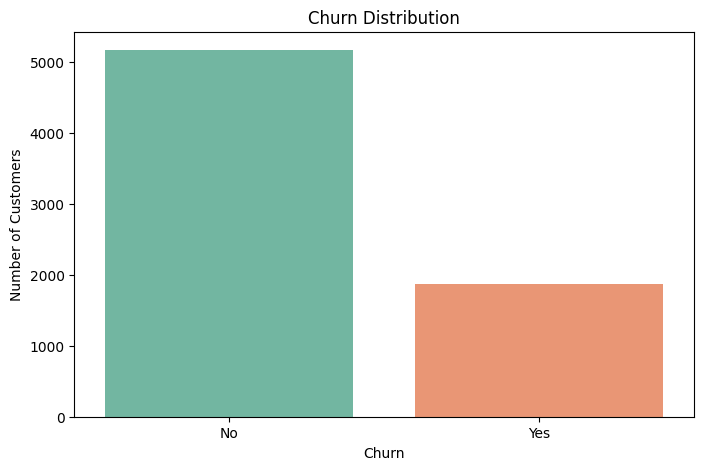

Stayed:  73.5%
Churned: 26.5%


In [8]:
# Visualize Churn Distribution (fixed)
plt.figure(figsize=(8, 5))
sns.countplot(x='Churn', data=df, hue='Churn', palette='Set2', legend=False)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

print(f"Stayed:  {stayed/total*100:.1f}%")
print(f"Churned: {churned/total*100:.1f}%")

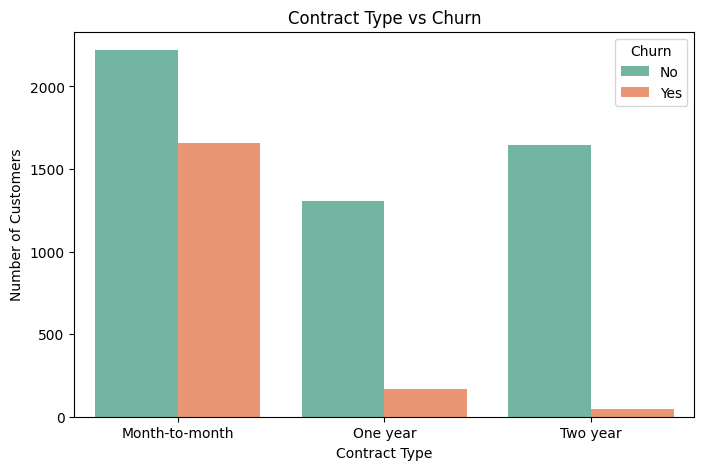

In [9]:
# Analyze Contract type vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', data=df, hue='Churn', palette='Set2')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

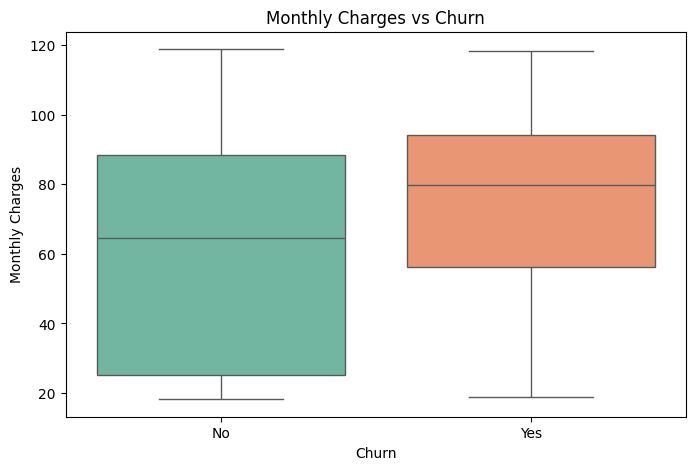

In [10]:
# Analyze Monthly Charges vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2', hue='Churn', legend=False)
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

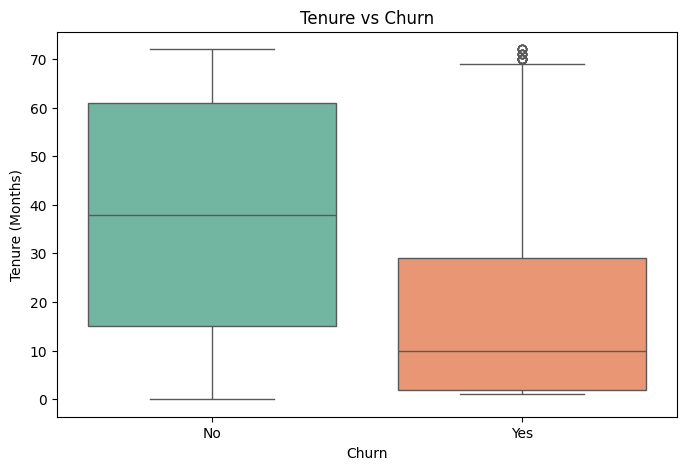

In [11]:
# Analyze Tenure vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='tenure', data=df, 
palette='Set2', hue='Churn', legend=False)
plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

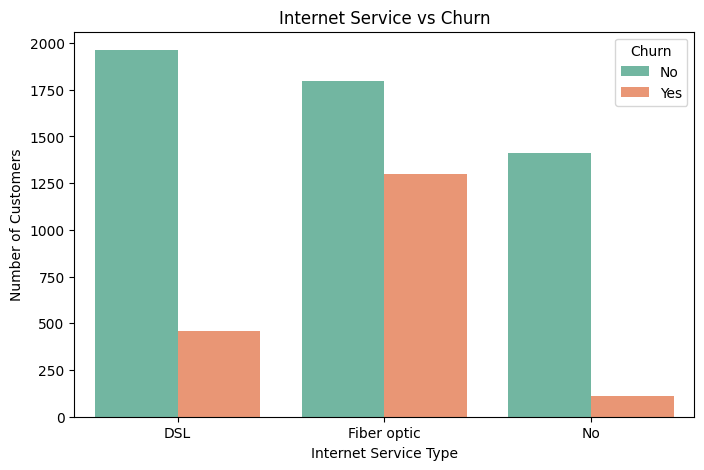

In [12]:
# Analyze Internet Service vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(x='InternetService', data=df, 
hue='Churn', palette='Set2')
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.show()

In [13]:
# Save cleaned data to processed folder
df.to_csv('../data/processed/churn_cleaned.csv', index=False)
print("✅ Cleaned data saved successfully!")

# Verify it saved
import os
print("File size:", os.path.getsize('../data/processed/churn_cleaned.csv'), "bytes")

✅ Cleaned data saved successfully!
File size: 978955 bytes
